In [1]:
import re
import string
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import  CountVectorizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

2021-09-17 23:59:02.925282: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/conda/lib
2021-09-17 23:59:02.925409: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
train_df = pd.read_csv('../input/nlp-getting-started/train.csv')

In [3]:
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [5]:
train_df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [6]:
train_df.drop(['id','keyword','location'], axis=1, inplace=True)

In [7]:
train_df.isnull().sum()

text      0
target    0
dtype: int64

Text(0, 0.5, 'Count')

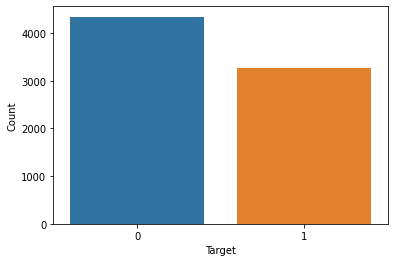

In [8]:
counts = train_df['target'].value_counts()
sns.barplot(x=counts.index, y=counts)
plt.xlabel('Target')
plt.ylabel('Count')

In [9]:
train_df['Text_length'] = train_df['text'].apply(len)

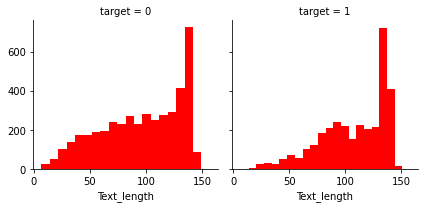

In [10]:
length_text = sns.FacetGrid(data=train_df, col='target')
length_text.map(plt.hist, 'Text_length', bins=20, color='r')

In [11]:
def plot_(a):
    x1 = train_df[train_df.target == 1][a]
    x2 = train_df[train_df.target == 0][a]
    plt.subplot(1,1,1)
    __= plt.hist(x2, alpha=0.5, color="grey", bins=50)
    _ = plt.hist(x1, alpha=0.8, color="red", bins=50)
    return __

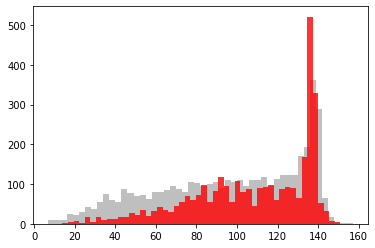

In [12]:
_ = plot_("Text_length")

In [13]:
train_df['words_counts'] = train_df.text.str.split().map(lambda x: len(x))

In [14]:
train_df.head()

,text,target,Text_length,words_counts
0,Our Deeds are the Reason of this #earthquake M...,1,69,13
1,Forest fire near La Ronge Sask. Canada,1,38,7
2,All residents asked to 'shelter in place' are ...,1,133,22
3,"13,000 people receive #wildfires evacuation or...",1,65,8
4,Just got sent this photo from Ruby #Alaska as ...,1,88,16


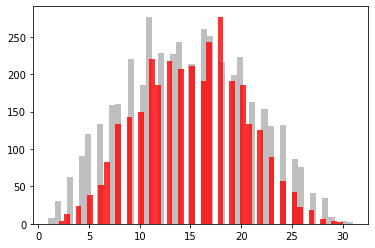

In [15]:
_ = plot_("words_counts")

In [16]:
train_df['punctuation_count'] = train_df['text'].map(lambda x: len([c for c in str(x) if c in string.punctuation]))

In [17]:
train_df.head()

,text,target,Text_length,words_counts,punctuation_count
0,Our Deeds are the Reason of this #earthquake M...,1,69,13,1
1,Forest fire near La Ronge Sask. Canada,1,38,7,1
2,All residents asked to 'shelter in place' are ...,1,133,22,3
3,"13,000 people receive #wildfires evacuation or...",1,65,8,2
4,Just got sent this photo from Ruby #Alaska as ...,1,88,16,2


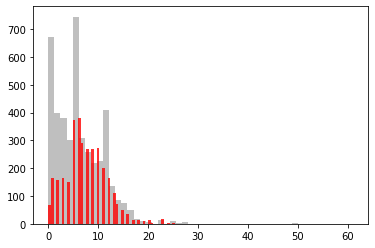

In [18]:
_ =plot_('punctuation_count')

In [19]:
def clean_text(text):
    text = text.lower()                                  # lower-case all characters
    text =  re.sub(r'@\S+', '',text)                     # remove twitter handles
    text =  re.sub(r'http\S+', '',text)                  # remove urls
    text =  re.sub(r'pic.\S+', '',text) 
    text =  re.sub(r"[^a-zA-Z+']", ' ',text)             # only keeps characters
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text+' ')      # keep words with length>1 only
    text = "".join([i for i in text if i not in string.punctuation])
    words = nltk.tokenize.word_tokenize(text)
    stopwords = nltk.corpus.stopwords.words('english')   # remove stopwords
    text = " ".join([i for i in words if i not in stopwords and len(i)>2])
    text= re.sub("\s[\s]+", " ",text).strip()            # remove repeated/leading/trailing spaces
    return text

In [20]:
train_df['Text_cleaning'] = train_df.text.apply(clean_text)

In [21]:
train_df.head()

,text,target,Text_length,words_counts,punctuation_count,Text_cleaning
0,Our Deeds are the Reason of this #earthquake M...,1,69,13,1,deeds reason earthquake may allah forgive
1,Forest fire near La Ronge Sask. Canada,1,38,7,1,forest fire near ronge sask canada
2,All residents asked to 'shelter in place' are ...,1,133,22,3,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",1,65,8,2,people receive wildfires evacuation orders cal...
4,Just got sent this photo from Ruby #Alaska as ...,1,88,16,2,got sent photo ruby alaska smoke wildfires pou...


(-0.5, 399.5, 199.5, -0.5)

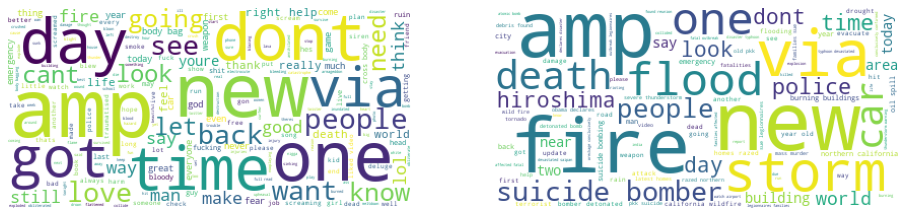

In [22]:
x_1 = train_df[train_df.target == 1]["Text_cleaning"]
x_0 = train_df[train_df.target == 0]["Text_cleaning"]
w_cloud_0 = WordCloud(background_color="white", max_font_size=80).generate(" ".join(x_0))
w_cloud_1 = WordCloud(background_color="white", max_font_size=80).generate(" ".join(x_1))
plt.figure(1,figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(w_cloud_0)
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(w_cloud_1)
plt.axis("off")

In [23]:
X = train_df['Text_cleaning']
y = train_df['target']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
def counter_word(text):
    count = Counter()
    for i in text.values:
        for word in i.split():
            count[word] += 1
    return count

In [26]:
text = train_df['Text_cleaning']
counter = counter_word(text)

In [27]:
train_df.describe()

,target,Text_length,words_counts,punctuation_count
count,7613.00000,7613.000000,7613.000000,7613.000000
mean,0.42966,101.037436,14.903586,6.839485
std,0.49506,33.781325,5.732604,4.608758
min,0.00000,7.000000,1.000000,0.000000
25%,0.00000,78.000000,11.000000,3.000000
50%,0.00000,107.000000,15.000000,6.000000
75%,1.00000,133.000000,19.000000,10.000000
max,1.00000,157.000000,31.000000,61.000000


In [28]:
len(counter)

13693

In [29]:
num_words = len(counter)
max_len = 157

In [30]:
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(X_train)

In [31]:
X_train = tokenizer.texts_to_sequences(X_train)
train_padded = pad_sequences(X_train,maxlen=max_len, truncating="post")

In [32]:
X_test = tokenizer.texts_to_sequences(X_test)
test_padded = pad_sequences(X_test,maxlen=max_len, truncating="post")

In [33]:
my_callbacks  = [EarlyStopping(monitor='val_loss',
                              min_delta=0,
                              patience=5,
                              mode='auto')]

In [34]:
model = Sequential()
model.add(Embedding(num_words, 32,input_length=max_len))
model.add(LSTM(64, dropout=0.2))
model.add(Dense(1, activation='sigmoid'))

2021-09-17 23:59:18.306777: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2021-09-17 23:59:18.310320: W tensorflow/stream_executor/platform/default/dso_loader.cc:60] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /opt/conda/lib
2021-09-17 23:59:18.310357: W tensorflow/stream_executor/cuda/cuda_driver.cc:326] failed call to cuInit: UNKNOWN ERROR (303)
2021-09-17 23:59:18.310384: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (9e1add1a11fe): /proc/driver/nvidia/version does not exist
2021-09-17 23:59:18.310730: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operation

In [35]:
model.compile(optimizer="Adam", loss="binary_crossentropy", metrics=["accuracy"])

In [36]:
history = model.fit(train_padded, y_train, epochs=100, validation_data=(test_padded, y_test), callbacks=my_callbacks)

2021-09-17 23:59:18.984949: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2021-09-17 23:59:18.998205: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 2199995000 Hz


Epoch 1/100
191/191 [==============================] - 25s 117ms/step - loss: 0.6435 - accuracy: 0.6218 - val_loss: 0.4543 - val_accuracy: 0.8011
Epoch 2/100
191/191 [==============================] - 22s 114ms/step - loss: 0.3220 - accuracy: 0.8709 - val_loss: 0.4585 - val_accuracy: 0.7892
Epoch 3/100
191/191 [==============================] - 22s 115ms/step - loss: 0.1984 - accuracy: 0.9263 - val_loss: 0.5397 - val_accuracy: 0.7866
Epoch 4/100
191/191 [==============================] - 21s 111ms/step - loss: 0.1400 - accuracy: 0.9477 - val_loss: 0.5945 - val_accuracy: 0.7761
Epoch 5/100
191/191 [==============================] - 21s 111ms/step - loss: 0.0997 - accuracy: 0.9651 - val_loss: 0.6841 - val_accuracy: 0.7695
Epoch 6/100
191/191 [==============================] - 21s 111ms/step - loss: 0.0714 - accuracy: 0.9752 - val_loss: 0.7396 - val_accuracy: 0.7663


In [37]:
results = model.evaluate(test_padded, y_test, verbose=0)
print("    Test Loss: {:.5f}".format(results[0]))
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

    Test Loss: 0.73963
Test Accuracy: 76.63%


In [38]:
y_pred = model.predict_classes(test_padded)
print(classification_report(y_test, y_pred))

/opt/conda/lib/python3.7/site-packages/tensorflow/python/keras/engine/sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


              precision    recall  f1-score   support

           0       0.77      0.84      0.80       874
           1       0.75      0.67      0.71       649

    accuracy                           0.77      1523
   macro avg       0.76      0.75      0.76      1523
weighted avg       0.77      0.77      0.76      1523



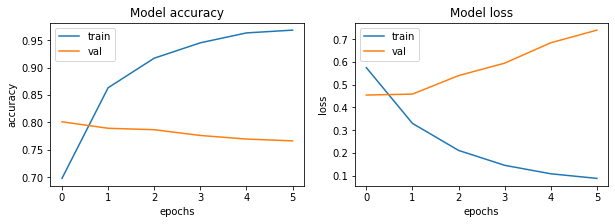

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax = ax.ravel()

for i, met in enumerate(['accuracy', 'loss']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].legend(['train', 'val']) 